CNN 학습 결과가 잘 나오는 MNIST 데이터셋으로 실습을 진행해봅시다!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import cv2
import matplotlib.pyplot as plt

In [2]:
# myCNN 클래스 정의
class myCNN(nn.Module):
    def __init__(self):
        super(myCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size = 5, padding = 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 5, padding = 2)
        self.conv3 = nn.Conv2d(64, 128, kernel_size = 5, padding = 2)
        self.fc1 = nn.Linear(128*3*3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = F.relu(F.max_pool2d(self.conv3(x), 2))
        x = x.view(-1, 128*3*3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim = 1)

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('./data', train = True, download = True, transform = transform)
test_dataset = datasets.MNIST('./data', train = False, transform = transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 64, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 1000, shuffle = False)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 40.0MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.73MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



모델, 손실 함수, 최적화 알고리즘 설정 ✅

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = myCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
test_losses = []
test_accuracies = []

모델 학습 ✅

In [5]:
def train(model, train_loader, optimizer, criterion, epoch):
    model.train()
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f"Epoch {epoch} [{batch_idx}/{len(train_loader)}] Loss: {loss.item():.4f}")

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch} Training Loss: {avg_loss:.4f}")

모델 평가 ✅

In [6]:
def test(model, test_loader, criterion):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += target.size(0)

    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total
    test_losses.append(avg_loss)
    test_accuracies.append(accuracy)
    print(f"Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")
    return accuracy

10회 반복 시행 ✅

In [7]:
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train(model, train_loader, optimizer, criterion, epoch)
    test(model, test_loader, criterion)

Epoch 1 [0/938] Loss: 2.3041
Epoch 1 [100/938] Loss: 0.0468
Epoch 1 [200/938] Loss: 0.1283
Epoch 1 [300/938] Loss: 0.0343
Epoch 1 [400/938] Loss: 0.0707
Epoch 1 [500/938] Loss: 0.0876
Epoch 1 [600/938] Loss: 0.0347
Epoch 1 [700/938] Loss: 0.0101
Epoch 1 [800/938] Loss: 0.0383
Epoch 1 [900/938] Loss: 0.0469
Epoch 1 Training Loss: 0.1345
Test Loss: 0.0391, Accuracy: 98.89%
Epoch 2 [0/938] Loss: 0.0069
Epoch 2 [100/938] Loss: 0.0137
Epoch 2 [200/938] Loss: 0.0234
Epoch 2 [300/938] Loss: 0.0129
Epoch 2 [400/938] Loss: 0.0029
Epoch 2 [500/938] Loss: 0.0370
Epoch 2 [600/938] Loss: 0.0846
Epoch 2 [700/938] Loss: 0.0352
Epoch 2 [800/938] Loss: 0.0069
Epoch 2 [900/938] Loss: 0.0535
Epoch 2 Training Loss: 0.0372
Test Loss: 0.0371, Accuracy: 98.95%
Epoch 3 [0/938] Loss: 0.1335
Epoch 3 [100/938] Loss: 0.0005
Epoch 3 [200/938] Loss: 0.0343
Epoch 3 [300/938] Loss: 0.0211
Epoch 3 [400/938] Loss: 0.0011
Epoch 3 [500/938] Loss: 0.0074
Epoch 3 [600/938] Loss: 0.0381
Epoch 3 [700/938] Loss: 0.0104
Epoch 

결과 시각화

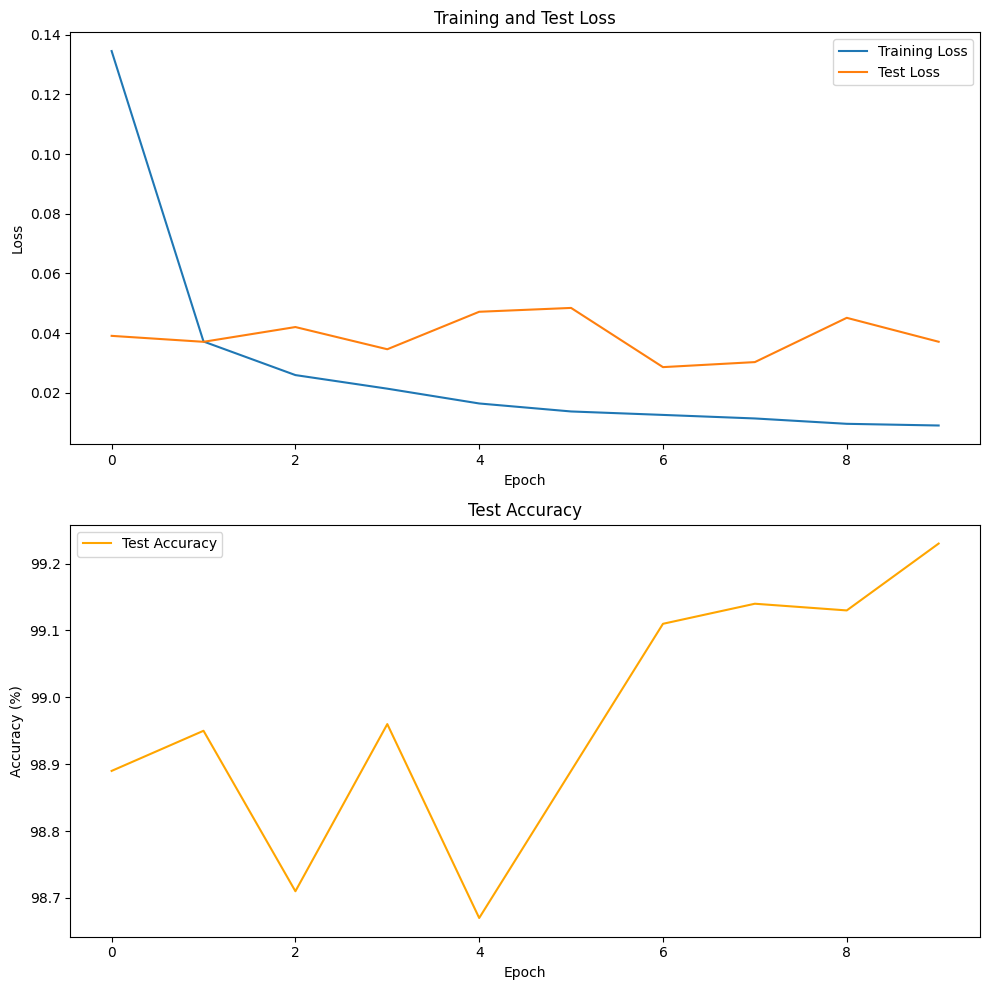

In [8]:
# 손실 및 정확도 시각화
fig, axs = plt.subplots(2,1,figsize=(10,10))
axs[0].plot(train_losses, label = 'Training Loss')
axs[0].plot(test_losses, label = 'Test Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].set_title('Training and Test Loss')

axs[1].plot(test_accuracies, label='Test Accuracy', color='orange')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy (%)')
axs[1].legend()
axs[1].set_title('Test Accuracy')

plt.tight_layout()
plt.show()